# SPHEREx Self-calibration Dev

In [1]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
# sys.path.insert(0, '/home/thomasli/spherex/selfcal')
from SelfCal import EuclidUtility
from SelfCal import WCSHelper
from SelfCal import MakeMap
from SelfCal import MapHelper
importlib.reload(MapHelper)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels,compute_chunk_contrib, det_to_grid
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame


In [2]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_mask, load_calibration, make_fiducial_chunk_map, extract_spherex_channel_edges, make_spherex_chunk_map, interp_2d_vertical

In [3]:
from SelfCal.MakeMap import *
from SelfCal.MapHelper import *

In [4]:
detector = 1

det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

In [5]:
chunk_map = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17)
chunk_valid_mask = make_fiducial_chunk_mask([4],  num_subchannels=10, num_channels=17)
det_valid_mask = chunk_valid_mask[chunk_map]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 172/172 [00:09<00:00, 17.74it/s]


In [ ]:
channel_edges = [0.87, 1.0]
chunk_map = make_spherex_chunk_map(detector, det_BC, fine_edges=channel_edges)
chunk_valid_mask = channel_edges==1

In [6]:
from SelfCal.MakeMap import _prep_subframe, load_reproj_file

In [1002]:
reproj_list = glob.glob('/data3/thomasli/selfcal/outputs/nep_det1_3p1arcsec/reprojected/*.h5')
reproj_sample = load_reproj_file(reproj_list[0], fields=['sub_data', 'sub_header', 'det_header', 
                                                         'ref_coords', 'file_path', 'grid_bitmask', 'grid_mapping', 'sub_foot'])

In [1003]:
reproj_sample['sub_data'].shape

(6305, 6305)

### _prep_subframe

In [14]:
file = reproj_list[0]
exp_idx = 0
det_idx = 0
chunk_map = chunk_map
det_valid_mask = det_valid_mask
apply_weight = False
apply_mask = True
chunk_offset = np.arange(len(chunk_valid_mask))
ignore_list = []
valid_threshold = 0.99
for_lsqr = True
interp_func = interp_2d_vertical

In [9]:
fields=['sub_data', 'ref_coords', 'grid_mapping']
if apply_mask:
    fields.append('grid_bitmask')
result = load_reproj_file(file, fields=fields)

data = result['sub_data']
coords = result['ref_coords']
grid_mapping = result['grid_mapping']

In [10]:
oversample_factor = 1
if grid_mapping is not None and data.shape[-1] > 0:
    oversample_factor = int(grid_mapping.shape[-1] / data.shape[-1])

sub_mask = np.ones_like(data, dtype=bool)
if 'grid_bitmask' in result:
    bitmask = result['grid_bitmask']
    sub_mask &= grid_bitmask_to_sub_mask(
        bitmask, oversample_factor, ignore_list=ignore_list, valid_threshold=valid_threshold
    )

In [ ]:
det_maps_to_process = []
map_keys = []
if chunk_offset is not None:
    offset_map = compute_offset_map(chunk_offset, chunk_map, interp_func=interp_func)
    det_maps_to_process.append(offset_map)
    map_keys.append('offset')
if det_valid_mask is not None:
    det_maps_to_process.append(det_valid_mask)
    map_keys.append('valid_mask')
if det_maps_to_process:
    stacked_det_maps = np.stack(det_maps_to_process, axis=0)
    stacked_grid_maps = det_to_grid(grid_mapping, stacked_det_maps)
    stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]
    # stacked_sub_maps = bin2d_cv(stacked_grid_maps, bin_factor=oversample_factor)
    if 'offset' in map_keys:
        data -= stacked_sub_maps[map_keys.index('offset')]
    if 'valid_mask' in map_keys:
        sub_mask &= (stacked_sub_maps[map_keys.index('valid_mask')] > 0.5)

In [21]:
stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]


In [936]:
chunk_map

array([[171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       ...,
       [  1,   1,   1, ...,   1,   1,   1],
       [  1,   1,   1, ...,   1,   1,   1],
       [  0,   0,   0, ...,   1,   1,   1]],
      shape=(2040, 2040), dtype=int16)

In [94]:
stacked_det_maps = np.stack(det_maps_to_process, axis=0)
stacked_grid_maps = [det_to_grid(grid_mapping, det_data=det_map) for det_map in stacked_det_maps]
stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]
# stacked_sub_maps = bin2d_cv(stacked_grid_maps, bin_factor=oversample_factor)
if 'offset' in map_keys:
    data -= stacked_sub_maps[map_keys.index('offset')]
if 'valid_mask' in map_keys:
    sub_mask &= (stacked_sub_maps[map_keys.index('valid_mask')] > 0.5)

In [36]:
data[~sub_mask] = np.nan

weight = make_weight(data) if apply_weight else np.ones_like(data, dtype=np.float32)

chunk_contrib = None
if for_lsqr:
    chunk_contrib = compute_chunk_contrib(
        grid_mapping=grid_mapping,
        chunk_map=chunk_map,
        oversample_factor=oversample_factor
    )

### Chunk Map

In [756]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, load_calibration, interpolate_array, make_arc_spline

In [815]:
importlib.reload(SPHERExUtility)


<module 'SelfCal.SPHERExUtility' from '/home/thomasli/spherex/selfcal/SelfCal/SPHERExUtility.py'>

In [816]:
detector = 1
det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
chunk_map, lvf_params = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17)

Fitting LVF contours...


  0%|                                                                                                                   | 0/171 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:03<00:00, 55.57it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:01<00:00, 142.78it/s]


In [817]:
chunk_map

array([[171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       ...,
       [  1,   1,   1, ...,   1,   1,   1],
       [  1,   1,   1, ...,   1,   1,   1],
       [  0,   0,   0, ...,   1,   1,   1]],
      shape=(2040, 2040), dtype=int16)

(0.0, 500.0)

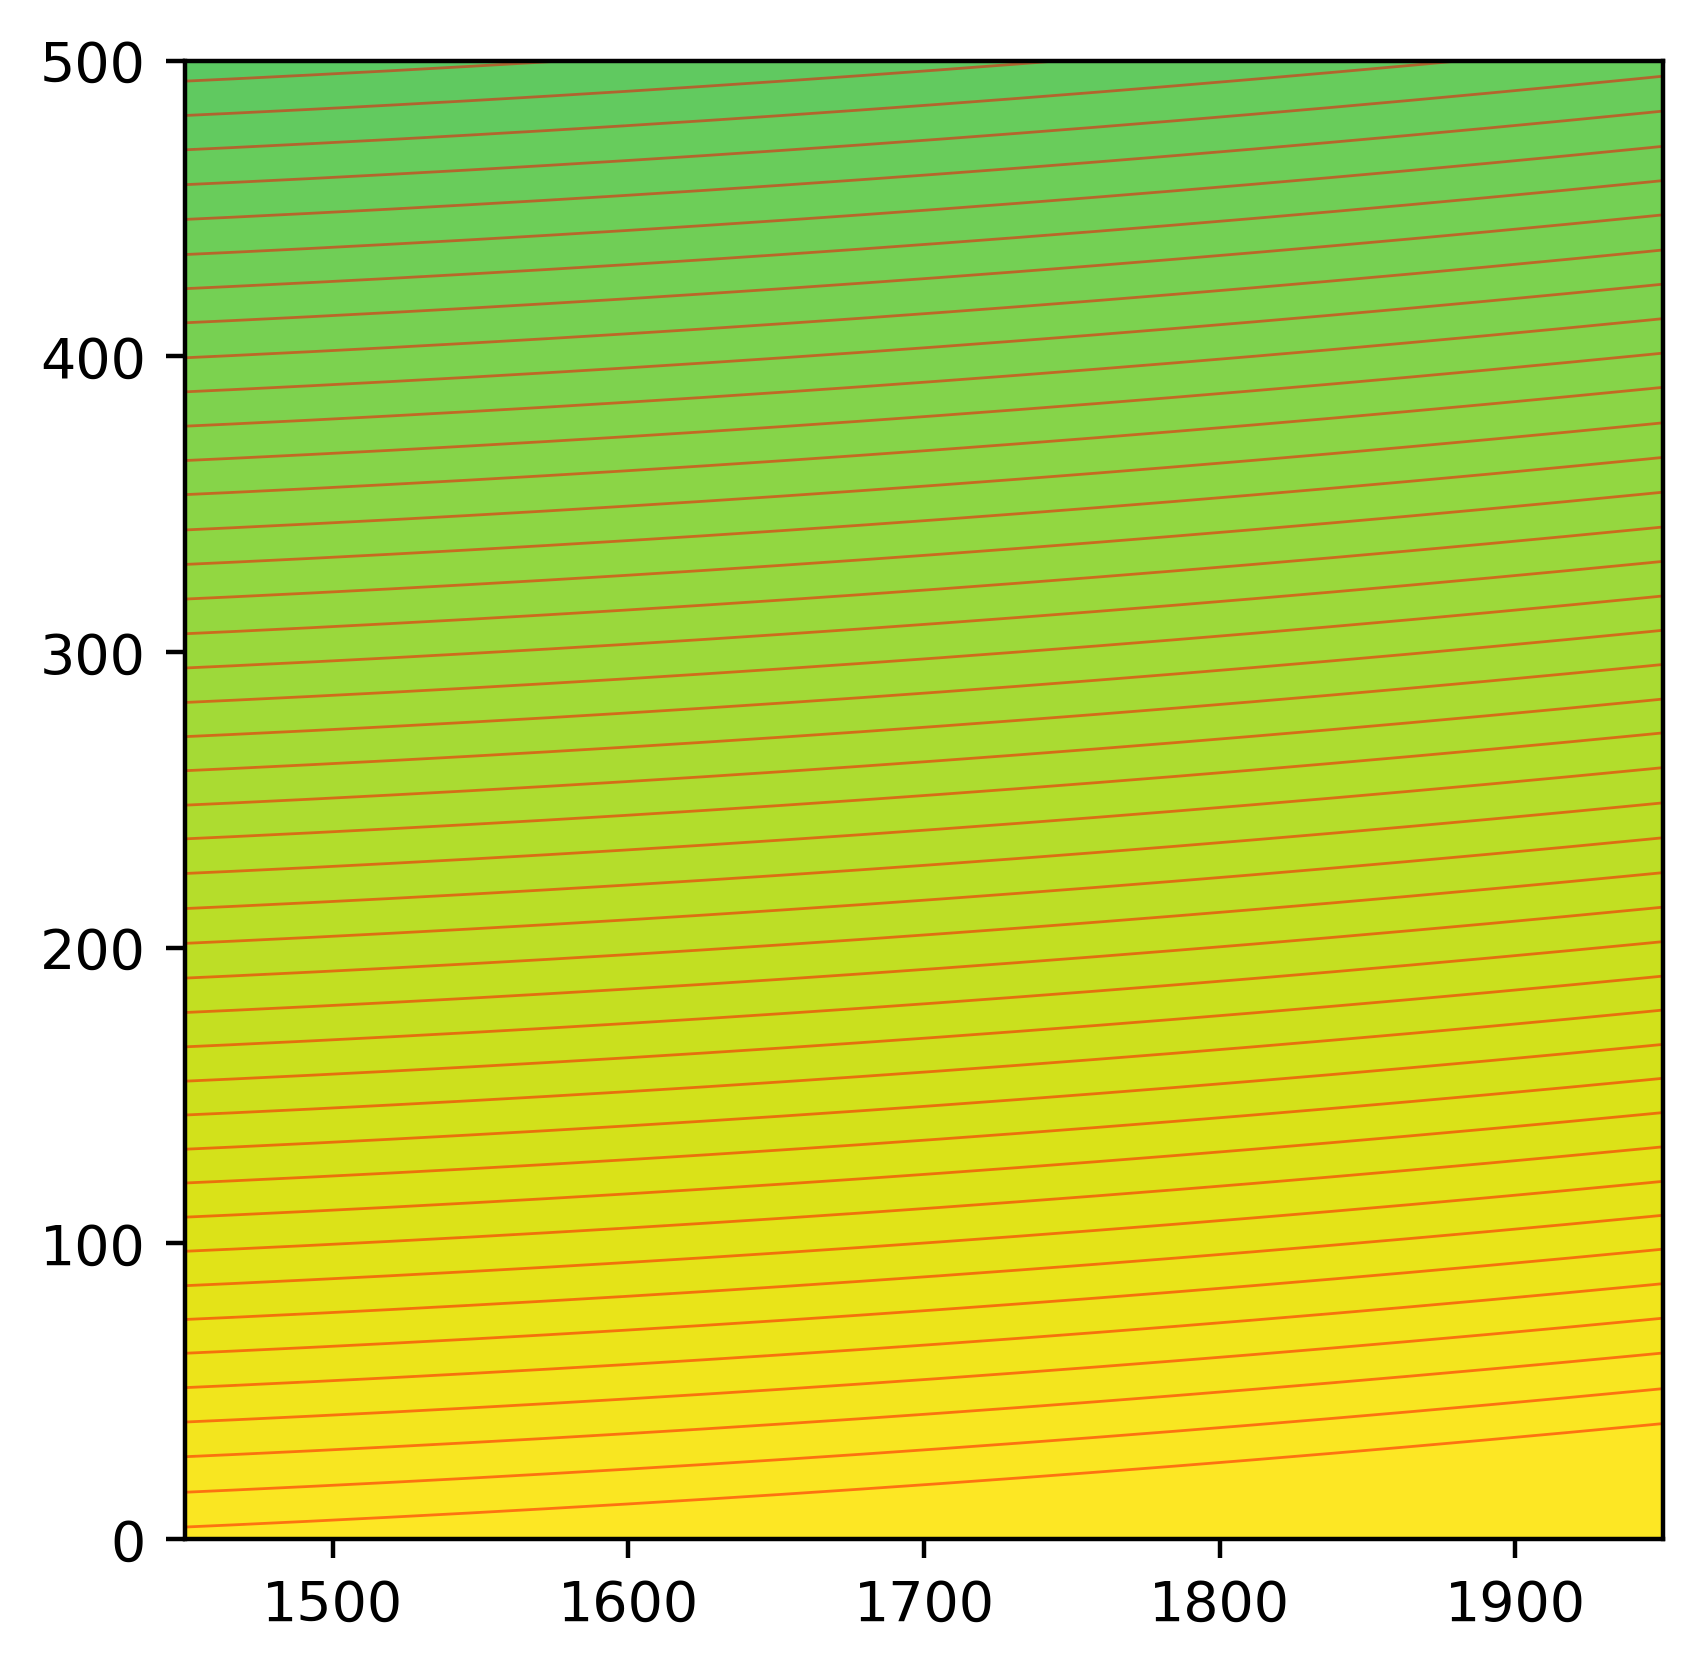

In [758]:
plt.imshow(chunk_map)
for i in range(len(lvf_params['R'])):
    spl = make_arc_spline(lvf_params['xc'], lvf_params['yc'], lvf_params['R'][i])
    x_arc = np.linspace(0, 2040, 1000)
    y_arc = spl(x_arc)
    plt.plot(x_arc, y_arc, 'r-', linewidth=0.5, alpha=0.5)
plt.xlim(1450, 1950)
plt.ylim(0, 500)

In [543]:
# plt.plot(fit_params['edge_index'], fit_params['xc'], '.')

### Correct Offset Map Ringing

In [796]:
wav_edge = lvf_params['wave_edges']
wav_med = 0.5 * (wav_edge[:-1] + wav_edge[1:])

chunk_offset = 0.5*np.arange(len(chunk_valid_mask))# + 10.0 * np.sin(0.5 * np.arange(len(chunk_valid_mask)))

In [926]:
chunk_offset[0:160] = 0
chunk_offset[170:] = 0

chunk_valid_mask = np.ones_like(chunk_offset, dtype=bool)
chunk_valid_mask[0:160] = 0
chunk_valid_mask[170:] = 0

In [785]:
from SelfCal.MapHelper import mean_preserving_spline

In [800]:
importlib.reload(MapHelper)

<module 'SelfCal.MapHelper' from '/home/thomasli/spherex/selfcal/SelfCal/MapHelper.py'>

In [909]:
lvf_params['R'][chunk_valid_mask[1:-1]]

IndexError: boolean index did not match indexed array along axis 0; size of axis is 171 but size of corresponding boolean axis is 170

In [912]:
edge_valid_mask = chunk_valid_mask[1:] | chunk_valid_mask[:-1]

In [927]:
R = lvf_params['R']
valid_R = R[edge_valid_mask]

spl = mean_preserving_spline(x_edge=valid_R, y_mean=chunk_offset[chunk_valid_mask])

In [883]:
# x = np.linspace(wav_med[0], wav_med[-1], 1000)
# y = spl(x)

# plt.plot(wav_med, chunk_offset[1:-1], ls='None', marker='.', markersize=1)
# plt.plot(x, y, '-', linewidth=0.5)

In [914]:
out_shape = (2040, 2040)
x_mesh, y_mesh = np.meshgrid(np.arange(out_shape[1]), np.arange(out_shape[0]))

rr = np.sqrt((x_mesh - lvf_params['xc'])**2 + (y_mesh - lvf_params['yc'])**2)
offset_map = spl(rr)

In [885]:
org_offset_map = interp_2d_vertical(chunk_offset[chunk_map])

In [938]:
# plt.imshow((org_offset_map*chunk_valid_mask[chunk_map])[100:200, -250:-150], vmin=79.5)

In [937]:
# plt.imshow((offset_map*chunk_valid_mask[chunk_map])[100:200, -250:-150], vmin=79.5)

### Examine Interpolation Methods

In [857]:
from SelfCal.SPHERExUtility import interp_1d, parse_bin

In [872]:
# x = np.arange(1000)
# org = np.exp(-(x-510)**2/100) + np.exp(-(x-530)**2/100) + (x/1000)**2 + \
#     np.exp(-(x-400)**2/100) + np.exp(-(x-410)**2/100) + np.exp(-(x-440)**2/100) + \
#      + np.exp(-(x-580)**2/10) + np.exp(-(x-630)**2/30) + np.exp(-(x-680)**2/60)
# binned = np.zeros_like(org)
# bin_size = int(2040/17/20)
# for i in range(0, len(org), bin_size):
#     binned[i:i+bin_size] = np.mean(org[i:i+bin_size])
# mpi = interp_1d(binned)
# lin = interp_1d(binned, method='linear')

# mean_idx, mean_val, _ = parse_bin(binned)
# # use pchip
# from scipy.interpolate import PchipInterpolator
# pchip_interp = PchipInterpolator(mean_idx, mean_val)
# scipy = pchip_interp(x)

# mean_idx, mean_val, edge = parse_bin(binned)
# mps_custom = mean_preserving_spline(edge, mean_val, method='cubic')
# mps_interp = mps_custom(x)

# plt.plot(x, org, label='Source', linewidth=1)
# # plt.plot(mean_idx, mean_val, 'o', label='Sampled Points', markersize=2, color='red')
# plt.step(x, binned, label='Binned', where='mid', linewidth=0.5, color='tab:red', alpha=0.7)
# # plt.plot(x, binned, label='Binned', linewidth=0.5)
# plt.plot(x, mpi, label='MPI Interpolated', ls='--', linewidth=0.5, color='tab:orange')
# plt.plot(x, lin, label='Linear Interpolated', ls='--', linewidth=0.5, color='tab:green')
# # plt.plot(x, mps_interp, label='Custom', linewidth=0.5, ls=':')


# # smaller legend
# plt.legend(fontsize='small')
# plt.xlim(350, 750)

### Reprojection

In [953]:
ref_wcs, ref_shape = load_from_fits('/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits')

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/ref.fits


In [ ]:
exposure_list = glob.glob(f'/mnt/md127/SPHEREx/reproc_data/deep_north/*/*/*/*D{detector}*.fits')
exp_file = exposure_list[0]

In [1029]:
ref_reso = np.abs(proj_plane_pixel_scales(ref_wcs)[0]) # Assuming square pixels
det_reso = np.abs(proj_plane_pixel_scales(det_wcs)[0])

reso_ratio = ref_reso / det_reso 

In [1031]:
method = 'exact'
file_path = exp_file
exp_idx = 0
det_idx = 0
sci_ext = 1
dq_ext = 2
ref_wcs = ref_wcs
sub_width = int(np.ceil(np.sqrt(2) * det_width / reso_ratio * (1 + 2 * padding_percentage)))
output_dir = '/home/thomasli/spherex/selfcal/test_dir/'
oversample_factor = 2
replace_existing = True

In [1032]:
# Save to HDF5
output_file = os.path.join(output_dir, f'exp_{exp_idx:04d}_det_{det_idx:02d}.h5')
reproj_funcs = {'exact': reproject_exact, 'interp': reproject_interp, 'adaptive': reproject_adaptive}
reproj_kwargs = {'parallel': 4}

In [1083]:
with fits.open(file_path) as hdul:
    det_data = hdul[sci_ext].data
    det_width = np.shape(det_data)[-1]
    det_header = hdul[sci_ext].header
    det_header_str = det_header.tostring().encode('utf-8')
    det_wcs = WCS(det_header)

    det_bitmask = hdul[dq_ext].data

In [1082]:
from astropy.wcs.utils import pixel_to_pixel
from SelfCal.MapHelper import bit_to_bool, bool_to_bit

In [1035]:
# Map detector center to world, then to reference frame pixels 
det_center = [det_data.shape[0] / 2.0, det_data.shape[1] / 2.0]           
ref_det_center = pixel_to_pixel(det_wcs, ref_wcs, det_center[1], det_center[0])

# Define sub-frame boundaries in the reference frame
ref_x_min = int(ref_det_center[0] - sub_width // 2)
ref_x_max = ref_x_min + sub_width
ref_y_min = int(ref_det_center[1] - sub_width // 2)
ref_y_max = ref_y_min + sub_width

# Create WCS for the sub-frame
sub_wcs = ref_wcs.deepcopy()
sub_wcs.wcs.crpix[0] -= ref_x_min # Adjust CRPIX for the sub-frame origin
sub_wcs.wcs.crpix[1] -= ref_y_min
sub_header_str = sub_wcs.to_header().tostring().encode('utf-8') 

In [1036]:
sub_data, sub_foot = reproj_funcs[method](
        (det_data, det_wcs), 
        sub_wcs, 
        shape_out=(sub_width, sub_width), 
        **reproj_kwargs
    )

In [ ]:
det_expanded_mask = bit_to_bool(det_bitmask, expand_bits=True)

In [ ]:
sub_expanded_mask, _ = reproject_interp(
        (det_expanded_mask[0], det_wcs), 
        sub_wcs, 
        shape_out=(sub_width, sub_width), 
        order='nearest-neighbor',
    )

TypeError: reproject_interp() got an unexpected keyword argument 'cval'

In [1096]:
sub_xmesh, sub_ymesh = np.meshgrid(np.arange(sub_width), np.arange(sub_width))

In [1125]:
det_to_sub_mapping = pixel_to_pixel(sub_wcs, det_wcs, sub_xmesh, sub_ymesh)

In [1127]:
plt.imshow(sub_foot)

Error in callback <function flush_figures at 0x70bd701c1120> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

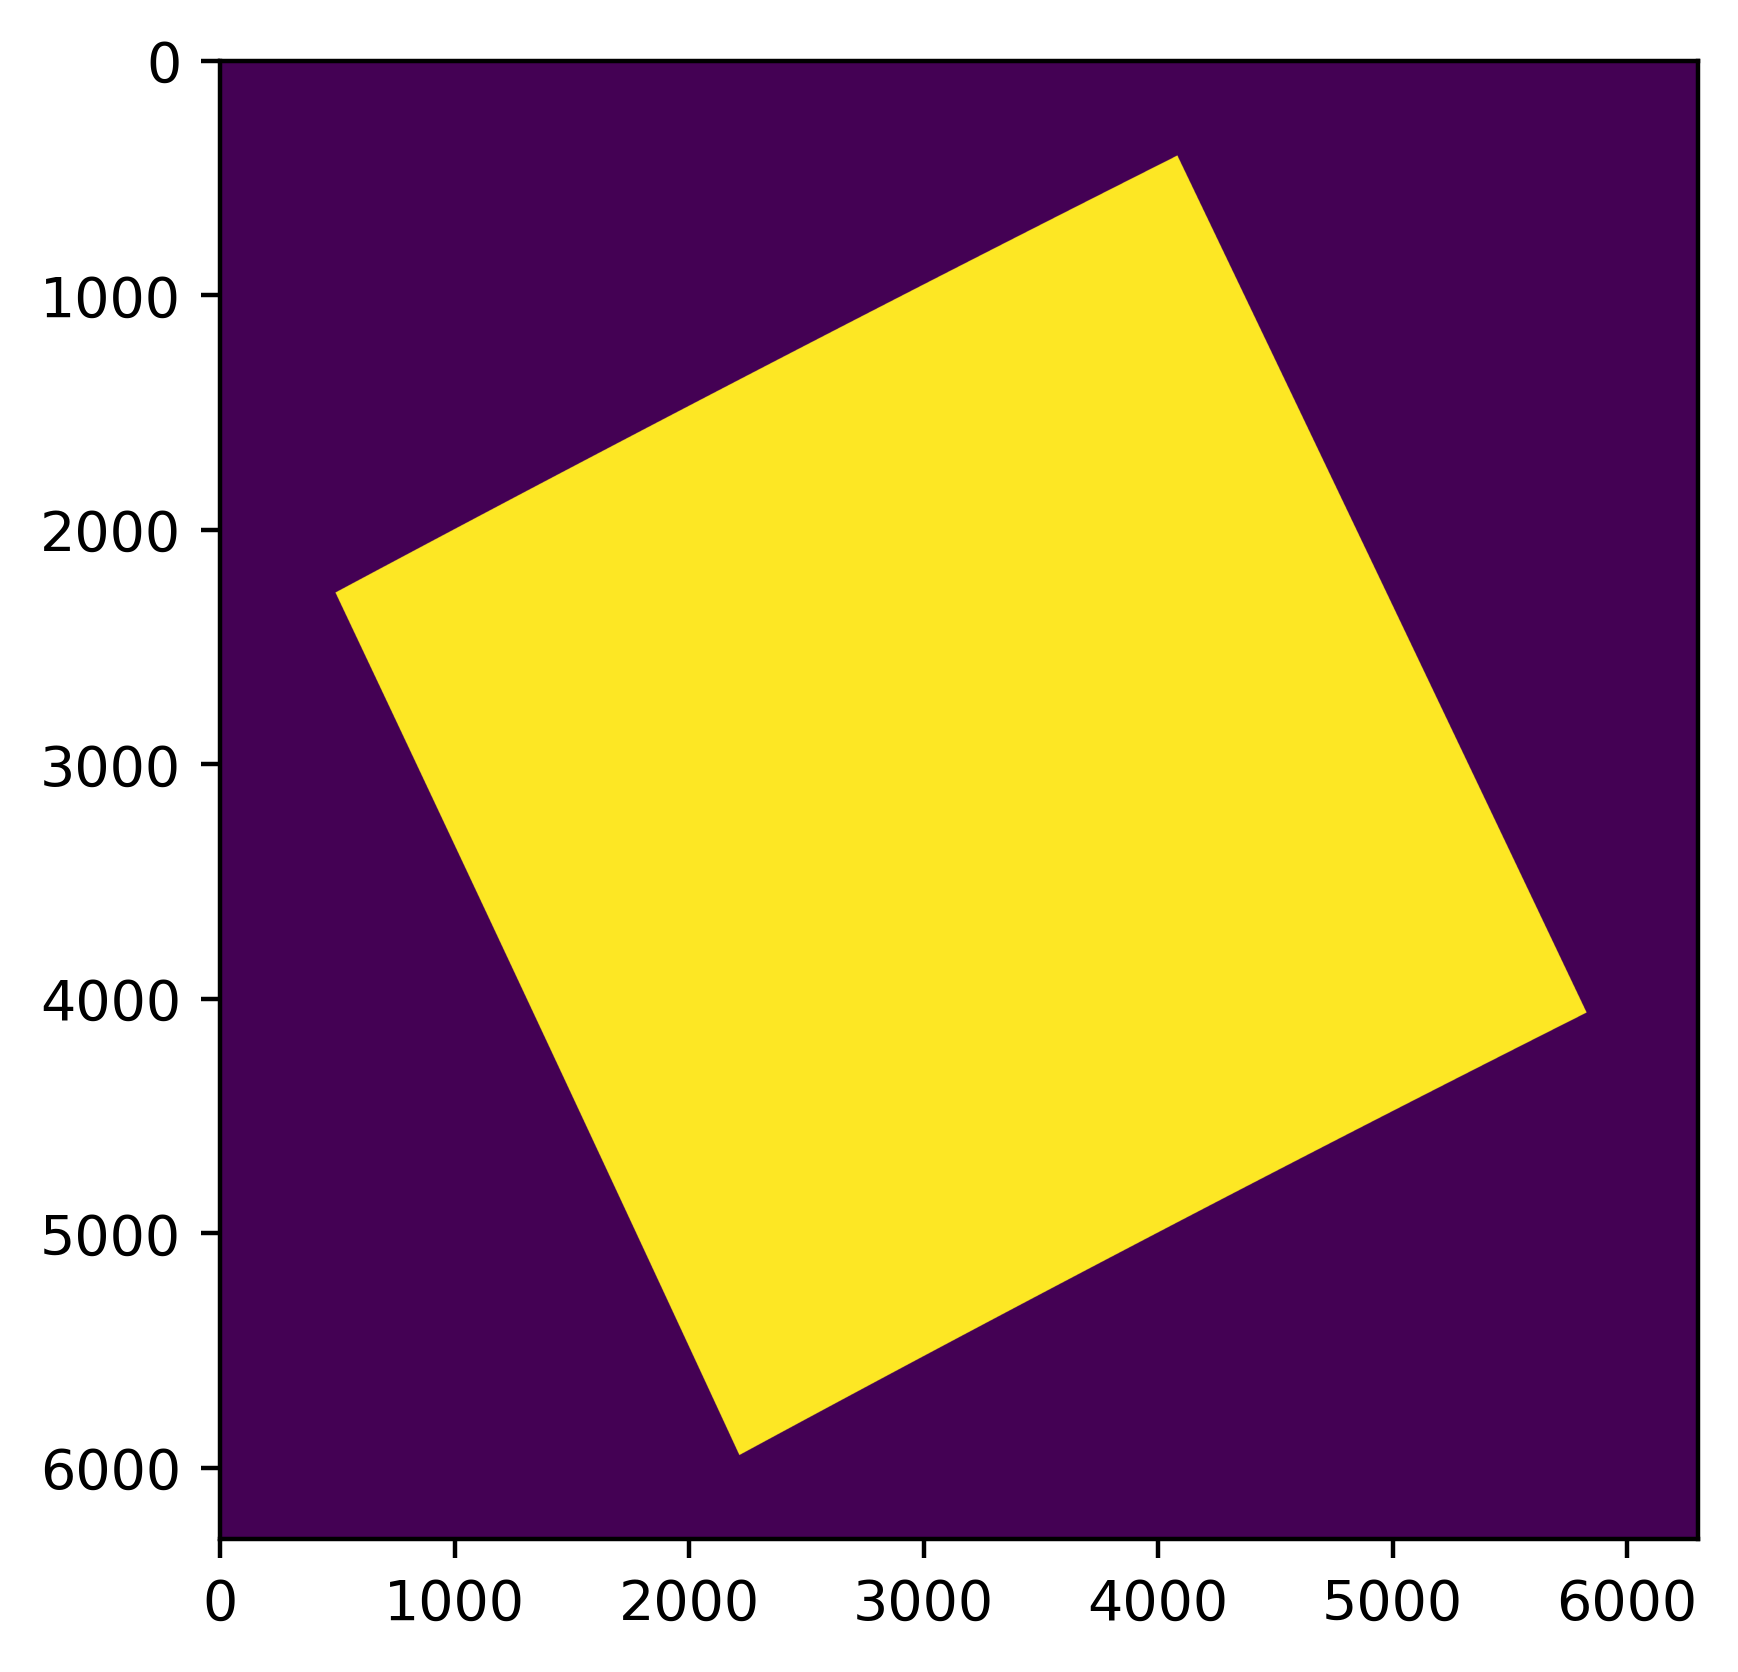

In [1126]:
plt.imshow(np.all([(det_to_sub_mapping[0]<2040), (det_to_sub_mapping[0]>=0), (det_to_sub_mapping[1]>=0), (det_to_sub_mapping[1]<2040)], axis=0))

In [1115]:
np.array(0.0).astype(np.bool)

array(False)

In [ ]:


det_to_sub_mapping[0]

array([[  267.87125153,   267.653423  ,   267.43559568, ...,
        -1072.18246015, -1072.38864268, -1072.5948228 ],
       [  268.3257321 ,   268.10790315,   267.89007541, ...,
        -1071.7330386 , -1071.93922228, -1072.14540355],
       [  268.78021394,   268.56238458,   268.34455642, ...,
        -1071.28361557, -1071.4898004 , -1071.69598282],
       ...,
       [ 3141.96471541,  3141.74530178,  3141.52588845, ...,
         1775.0213162 ,  1774.80839496,  1774.59547542],
       [ 3142.41992588,  3142.20051217,  3141.98109877, ...,
         1775.47319342,  1775.26027122,  1775.04735072],
       [ 3142.87513532,  3142.65572154,  3142.43630807, ...,
         1775.92506994,  1775.71214679,  1775.49922534]],
      shape=(6305, 6305))

In [1069]:
mask_contract = np.any(mask_expand, axis=0)

In [1074]:
mask_recov = bool_to_bit(mask_expand)

In [1078]:
det_mask

array([[ 524288,       0,       0, ..., 2097152, 2097152, 2097152],
       [      0,       0,       0, ..., 2097152, 2097152, 2097152],
       [      0,       0,       0, ..., 2097152, 2097216, 2097152],
       ...,
       [2097152, 2097152, 2097152, ..., 2097152, 2097152, 2097152],
       [2097152, 2097152, 2097152, ..., 2097152, 2097152, 2097152],
       [2097152, 2097152, 2097152, ..., 2097152, 2097152, 2097152]],
      shape=(2040, 2040), dtype='>i4')